In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.stats.stattools import jarque_bera

PATH = "combined.csv"
df = pd.read_csv(PATH)

# Parse DATE in DD/MM/YYYY
df["DATE"] = pd.to_datetime(df["DATE"], dayfirst=True, errors="coerce")
df = df.dropna(subset=["DATE"]).copy()

# Create month start timestamp
df["MONTH"] = df["DATE"].dt.to_period("M").dt.to_timestamp()

# ============================================================
# Restrict dataset to Jan 2023 – Aug 2025
# ============================================================

START_DATE = pd.Timestamp("2023-01-01")
END_DATE = pd.Timestamp("2025-08-31")

df = df[(df["DATE"] >= START_DATE) & (df["DATE"] <= END_DATE)].copy()

# Recompute MONTH index range explicitly (optional but clean)
df["MONTH"] = df["DATE"].dt.to_period("M").dt.to_timestamp()

print("Filtered date range:")
print(df["DATE"].min(), "to", df["DATE"].max())
print("Total rows:", len(df))

print(df.shape)
df.head()

Filtered date range:
2023-01-01 00:00:00 to 2025-08-31 00:00:00
Total rows: 484374
(484374, 14)


,DATE,FROM,TO,AIRCRAFT,FLIGHT TIME,STD,ATD,STA,STATUS,FLIGHT NUMBER,AIRLINE,# OF SEATS,LOAD FACTOR,MONTH
16,2025-08-31,Manila (MNL),Bacolod City (BCD),A20N (RP-C4266),NaN,10:15:00,NaN,11:40:00,Canceled,5J483,Cebu Pacific,186.0,151.218,2025-08-01
17,2025-08-30,Manila (MNL),Bacolod City (BCD),A21N (RP-C4121),0:57:00,11:30:00,11:50:00,12:55:00,Landed 12:47 PM,5J483,Cebu Pacific,230.0,186.990,2025-08-01
18,2025-08-30,Manila (MNL),Bacolod City (BCD),A21N (RP-C4121),NaN,10:15:00,NaN,12:55:00,Unknown,5J483,Cebu Pacific,230.0,186.990,2025-08-01
19,2025-08-28,Manila (MNL),Bacolod City (BCD),A321 (RP-C4117),0:57:00,10:15:00,10:36:00,11:40:00,Landed 11:33 AM,5J483,Cebu Pacific,230.0,186.990,2025-08-01
20,2025-08-27,Manila (MNL),Bacolod City (BCD),A21N (RP-C4126),0:55:00,10:15:00,11:07:00,11:40:00,Landed 12:02 PM,5J483,Cebu Pacific,230.0,186.990,2025-08-01


In [ ]:
def monthly_count_series(df_in, mask=None, start=None, end=None):
    """
    Returns monthly flight count series (freq='MS'), filling missing months with 0.
    mask: optional boolean mask on df_in
    """
    tmp = df_in.copy()
    if mask is not None:
        tmp = tmp[mask].copy()

    s = tmp.groupby("MONTH").size().sort_index()

    if start is None:
        start = df_in["MONTH"].min()
    if end is None:
        end = df_in["MONTH"].max()

    full_idx = pd.date_range(start, end, freq="MS")
    return s.reindex(full_idx, fill_value=0).astype(float)

In [ ]:
# (1) Network-wide (all airlines)
y_network = monthly_count_series(df)

# (2) Cebu Pacific network only
# Adjust this keyword if your AIRLINE column uses "5J" etc.
CEBPAC_KEYWORD = "CEBU PACIFIC"

mask_cebpac = df["AIRLINE"].astype(str).str.upper().str.contains(CEBPAC_KEYWORD, na=False)
y_cebpac = monthly_count_series(df, mask=mask_cebpac)

# (3) Route-level series (aggregate airlines)
def route_mask(o, d):
    return (df["FROM"] == o) & (df["TO"] == d)

y_ceb_cbo = monthly_count_series(df, mask=route_mask("Cebu (CEB)", "Cotabato (CBO)"))
y_ceb_crm = monthly_count_series(df, mask=route_mask("Cebu (CEB)", "Catarman (CRM)"))
y_mnl_cbo = monthly_count_series(df, mask=route_mask("Manila (MNL)", "Cotabato (CBO)"))

y_mnl_bso = monthly_count_series(df, mask=route_mask("Manila (MNL)", "Basco (BSO)"))
y_crk_bso = monthly_count_series(df, mask=route_mask("Angeles City (CRK)", "Basco (BSO)"))

y_ceb_bpa = monthly_count_series(df, mask=route_mask("Cebu (CEB)", "Borongan (BPA)"))
y_mnl_crm = monthly_count_series(df, mask=route_mask("Manila (MNL)", "Catarman (CRM)"))
y_mnl_cyp = monthly_count_series(df, mask=route_mask("Manila (MNL)", "Calbayog (CYP)"))
y_mnl_euq = monthly_count_series(df, mask=route_mask("Manila (MNL)", "San Jose de Buenavista (EUQ)"))
y_cbo_twt = monthly_count_series(df, mask=route_mask("Cotabato (CBO)", "Tawi Tawi (TWT)"))

series_dict = {
    "Network_AllAirlines": y_network,
    "CebuPacific_Network": y_cebpac,
    "Route_CEB-CBO": y_ceb_cbo,
    "Route_CEB-CRM": y_ceb_crm,
    "Route_MNL-CBO": y_mnl_cbo,

    "Route_MNL-BSO": y_mnl_bso,
    "Route_CRK-BSO": y_crk_bso,

    "Route_CEB-BPA": y_ceb_bpa,
    "Route_MNL-CRM": y_mnl_crm,
    "Route_MNL-CYP": y_mnl_cyp,
    "Route_MNL-EUQ": y_mnl_euq,
    "Route_CBO-TWT": y_cbo_twt,

}

{ k: (v.index.min().date(), v.index.max().date(), int(v.sum())) for k, v in series_dict.items() }

{'Network_AllAirlines': (datetime.date(2023, 1, 1),
  datetime.date(2025, 8, 1),
  484374),
 'CebuPacific_Network': (datetime.date(2023, 1, 1),
  datetime.date(2025, 8, 1),
  196357),
 'Route_CEB-CBO': (datetime.date(2023, 1, 1), datetime.date(2025, 8, 1), 242),
 'Route_CEB-CRM': (datetime.date(2023, 1, 1), datetime.date(2025, 8, 1), 74),
 'Route_MNL-CBO': (datetime.date(2023, 1, 1), datetime.date(2025, 8, 1), 992),
 'Route_MNL-BSO': (datetime.date(2023, 1, 1), datetime.date(2025, 8, 1), 875),
 'Route_CRK-BSO': (datetime.date(2023, 1, 1), datetime.date(2025, 8, 1), 228),
 'Route_CEB-BPA': (datetime.date(2023, 1, 1), datetime.date(2025, 8, 1), 316),
 'Route_MNL-CRM': (datetime.date(2023, 1, 1), datetime.date(2025, 8, 1), 532),
 'Route_MNL-CYP': (datetime.date(2023, 1, 1), datetime.date(2025, 8, 1), 440),
 'Route_MNL-EUQ': (datetime.date(2023, 1, 1), datetime.date(2025, 8, 1), 401),
 'Route_CBO-TWT': (datetime.date(2023, 1, 1), datetime.date(2025, 8, 1), 215)}

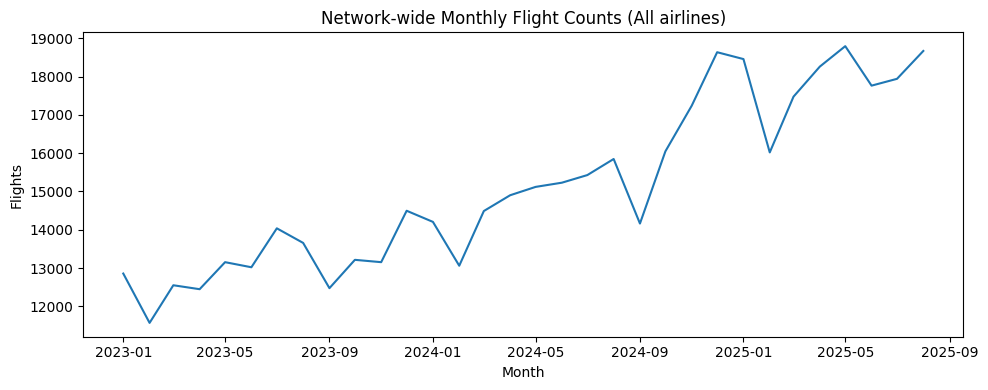

In [ ]:
plt.figure(figsize=(10,4))
plt.plot(y_network.index, y_network.values)
plt.title("Network-wide Monthly Flight Counts (All airlines)")
plt.xlabel("Month")
plt.ylabel("Flights")
plt.tight_layout()
plt.show()

In [ ]:
def train_test_split_ts(y, test_months=6):
    y = y.sort_index()
    if len(y) <= test_months + 12:
        test_months = max(1, min(test_months, len(y)//4))
    return y.iloc[:-test_months], y.iloc[-test_months:]

TEST_MONTHS = 6

In [ ]:
def mae(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(np.abs(y_true - y_pred)))

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.sqrt(np.mean((y_true - y_pred)**2)))

def mape_safe(y_true, y_pred, eps=1.0):
    """
    Stabilized MAPE for counts.
    Uses max(eps, abs(actual)) in denominator to avoid exploding when actual=0.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(eps, np.abs(y_true))
    return float(np.mean(np.abs((y_true - y_pred) / denom)) * 100)

def smape(y_true, y_pred, eps=1.0):
    """
    Symmetric MAPE; more stable with zeros.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = np.maximum(eps, (np.abs(y_true) + np.abs(y_pred)) / 2.0)
    return float(np.mean(np.abs(y_true - y_pred) / denom) * 100)

def seasonal_naive_forecast(y_train, h, season=12):
    """
    Seasonal naive: forecast equals value from same month last year.
    If not enough history, fall back to last observed.
    """
    y_train = y_train.values
    if len(y_train) > season:
        last_season = y_train[-season:]
        reps = int(np.ceil(h / season))
        fc = np.tile(last_season, reps)[:h]
    else:
        fc = np.repeat(y_train[-1], h)
    return fc

def mase(y_train, y_test, y_pred, season=12):
    """
    Mean Absolute Scaled Error compared to seasonal naive.
    MASE < 1 means better than seasonal naive baseline.
    """
    y_train = np.asarray(y_train)
    # in-sample seasonal naive errors
    if len(y_train) <= season:
        return np.nan

    insample_true = y_train[season:]
    insample_pred = y_train[:-season]
    scale = np.mean(np.abs(insample_true - insample_pred))
    if scale == 0:
        return np.nan

    return float(np.mean(np.abs(np.asarray(y_test) - np.asarray(y_pred))) / scale)

In [ ]:
# ============================================================
# PRE-CHECKS FOR ARIMA / SARIMA ASSUMPTIONS
# ============================================================

def check_series_assumptions(y, label="", seasonal_period=12, do_plots=True):
    """
    Basic pre-checks for ARIMA/SARIMA suitability.
    Prints:
      - length, zeros, mean/std
      - ADF test
      - KPSS test
    Plots:
      - time series
      - ACF / PACF
      - first difference
      - seasonal difference (if enough data)
    """

    y = y.dropna().astype(float)

    print("\n====================================================")
    print(f"PRE-CHECKS: {label}")
    print("====================================================")
    print(f"N observations: {len(y)}")
    print(f"Date range: {y.index.min().date()} to {y.index.max().date()}")
    print(f"Mean: {y.mean():.2f}")
    print(f"Std dev: {y.std():.2f}")
    print(f"Min / Max: {y.min():.2f} / {y.max():.2f}")
    print(f"Zero months: {(y == 0).sum()}")

    # ADF: H0 = non-stationary
    try:
        adf_res = adfuller(y, autolag="AIC")
        print("\nADF test")
        print(f"  Statistic: {adf_res[0]:.4f}")
        print(f"  p-value:   {adf_res[1]:.4f}")
        print("  Interpretation:", "Stationary (reject H0)" if adf_res[1] < 0.05 else "Non-stationary (fail to reject H0)")
    except Exception as e:
        print("\nADF test failed:", e)

    # KPSS: H0 = stationary
    try:
        kpss_res = kpss(y, regression="c", nlags="auto")
        print("\nKPSS test")
        print(f"  Statistic: {kpss_res[0]:.4f}")
        print(f"  p-value:   {kpss_res[1]:.4f}")
        print("  Interpretation:", "Non-stationary (reject H0)" if kpss_res[1] < 0.05 else "Stationary (fail to reject H0)")
    except Exception as e:
        print("\nKPSS test failed:", e)

    if do_plots:
        fig, axes = plt.subplots(2, 2, figsize=(12, 8))

        # original series
        axes[0, 0].plot(y.index, y.values)
        axes[0, 0].set_title(f"{label} – Original Series")
        axes[0, 0].set_ylabel("Flights")

        # first difference
        y_diff = y.diff().dropna()
        axes[0, 1].plot(y_diff.index, y_diff.values)
        axes[0, 1].set_title(f"{label} – First Difference")

        # ACF original
        plot_acf(y, ax=axes[1, 0], lags=min(24, len(y)-1))
        axes[1, 0].set_title(f"{label} – ACF")

        # PACF original
        try:
            plot_pacf(y, ax=axes[1, 1], lags=min(24, len(y)//2 - 1), method="ywm")
            axes[1, 1].set_title(f"{label} – PACF")
        except Exception:
            axes[1, 1].text(0.1, 0.5, "PACF not available", fontsize=12)

        plt.tight_layout()
        plt.show()

        # seasonal differencing check
        if len(y) > seasonal_period:
            y_seasdiff = y.diff(seasonal_period).dropna()

            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            axes[0].plot(y_seasdiff.index, y_seasdiff.values)
            axes[0].set_title(f"{label} – Seasonal Difference ({seasonal_period})")

            plot_acf(y_seasdiff, ax=axes[1], lags=min(24, len(y_seasdiff)-1))
            axes[1].set_title(f"{label} – ACF of Seasonal Difference")

            plt.tight_layout()
            plt.show()

In [ ]:
def fit_sarimax(y_train, order, seasonal_order=(0,0,0,0)):
    model = SARIMAX(
        y_train,
        order=order,
        seasonal_order=seasonal_order,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res = model.fit(disp=False)
    return res

def predict_steps(res, steps):
    return res.get_forecast(steps=steps).predicted_mean

In [ ]:
def grid_search_sarimax(y, test_months=6, seasonal_period=12,
                        arima_orders=None,
                        sarima_orders=None):
    """
    Returns a DataFrame of candidate models with AIC + test metrics.
    - arima_orders: list of (p,d,q)
    - sarima_orders: list of ((p,d,q), (P,D,Q,seasonal_period))
    """
    y_train, y_test = train_test_split_ts(y, test_months=test_months)
    h = len(y_test)

    rows = []

    # Default grids (kept small so it runs in reasonable time)
    if arima_orders is None:
        arima_orders = [(p,d,q) for p in range(0,4) for d in [0,1] for q in range(0,4)]

    if sarima_orders is None:
        sarima_orders = []
        for p in range(0,3):
            for d in [0,1]:
                for q in range(0,3):
                    for P in range(0,2):
                        for D in [0,1]:
                            for Q in range(0,2):
                                sarima_orders.append(((p,d,q), (P,D,Q,seasonal_period)))

    # ARIMA candidates
    for order in arima_orders:
        try:
            res = fit_sarimax(y_train, order=order, seasonal_order=(0,0,0,0))
            fc = predict_steps(res, h)

            rows.append({
                "model": "ARIMA",
                "order": order,
                "seasonal_order": (0,0,0,0),
                "aic": res.aic,
                "mae": mae(y_test, fc),
                "rmse": rmse(y_test, fc),
                "mape": mape_safe(y_test, fc),
                "smape": smape(y_test, fc),
                "mase": mase(y_train, y_test, fc, season=seasonal_period),
            })
        except Exception:
            continue

    # SARIMA candidates
    for order, seas in sarima_orders:
        try:
            res = fit_sarimax(y_train, order=order, seasonal_order=seas)
            fc = predict_steps(res, h)

            rows.append({
                "model": "SARIMA",
                "order": order,
                "seasonal_order": seas,
                "aic": res.aic,
                "mae": mae(y_test, fc),
                "rmse": rmse(y_test, fc),
                "mape": mape_safe(y_test, fc),
                "smape": smape(y_test, fc),
                "mase": mase(y_train, y_test, fc, season=seasonal_period),
            })
        except Exception:
            continue

    out = pd.DataFrame(rows)
    if out.empty:
        return out

    # Rank primarily by MAE (you can switch to MASE if you prefer)
    out = out.sort_values(["mae", "rmse", "aic"]).reset_index(drop=True)
    return out

In [ ]:
# ============================================================
# POST-FIT RESIDUAL CHECKS
# ============================================================

def residual_diagnostics(fitted_result, y_train, label=""):
    """
    Checks whether residuals behave like white noise.
    Works for SARIMAX results.
    """
    resid = pd.Series(fitted_result.resid).dropna()

    print("\n====================================================")
    print(f"RESIDUAL DIAGNOSTICS: {label}")
    print("====================================================")
    print(f"Residual mean: {resid.mean():.4f}")
    print(f"Residual std:  {resid.std():.4f}")

    # Ljung-Box: H0 = no autocorrelation
    try:
        lb = acorr_ljungbox(resid, lags=[6, 12], return_df=True)
        print("\nLjung-Box test")
        print(lb)
    except Exception as e:
        print("\nLjung-Box failed:", e)

    # Jarque-Bera: H0 = normal residuals
    try:
        jb_stat, jb_p, skew, kurt = jarque_bera(resid)
        print("\nJarque-Bera test")
        print(f"  JB stat: {jb_stat:.4f}")
        print(f"  p-value: {jb_p:.4f}")
        print(f"  skew:    {skew:.4f}")
        print(f"  kurtosis:{kurt:.4f}")
    except Exception as e:
        print("\nJarque-Bera failed:", e)

    # ARCH test: H0 = no ARCH / no changing variance
    try:
        arch_stat, arch_p, _, _ = het_arch(resid)
        print("\nARCH test")
        print(f"  Statistic: {arch_stat:.4f}")
        print(f"  p-value:   {arch_p:.4f}")
    except Exception as e:
        print("\nARCH test failed:", e)

    # plots
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    axes[0, 0].plot(resid.index, resid.values)
    axes[0, 0].axhline(0, linestyle="--")
    axes[0, 0].set_title(f"{label} – Residuals")

    axes[0, 1].hist(resid.values, bins=12)
    axes[0, 1].set_title(f"{label} – Residual Histogram")

    plot_acf(resid, ax=axes[1, 0], lags=min(24, len(resid)-1))
    axes[1, 0].set_title(f"{label} – Residual ACF")

    axes[1, 1].scatter(fitted_result.fittedvalues, resid.values)
    axes[1, 1].axhline(0, linestyle="--")
    axes[1, 1].set_title(f"{label} – Residuals vs Fitted")
    axes[1, 1].set_xlabel("Fitted")
    axes[1, 1].set_ylabel("Residuals")

    plt.tight_layout()
    plt.show()


PRE-CHECKS: Network (All airlines)
N observations: 32
Date range: 2023-01-01 to 2025-08-01
Mean: 15136.69
Std dev: 2208.57
Min / Max: 11567.00 / 18795.00
Zero months: 0

ADF test
  Statistic: 0.7459
  p-value:   0.9907
  Interpretation: Non-stationary (fail to reject H0)

KPSS test
  Statistic: 0.8666
  p-value:   0.0100
  Interpretation: Non-stationary (reject H0)


/tmp/ipykernel_493/3207610546.py:43: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(y, regression="c", nlags="auto")


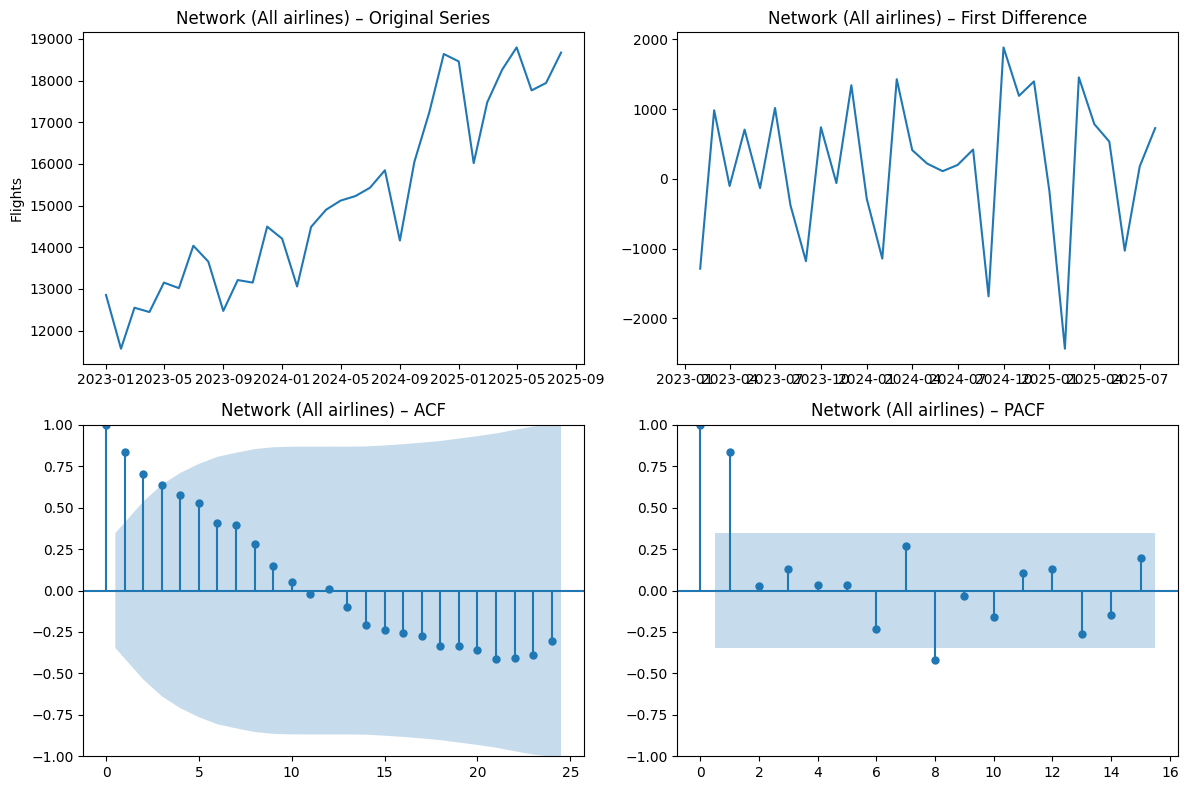

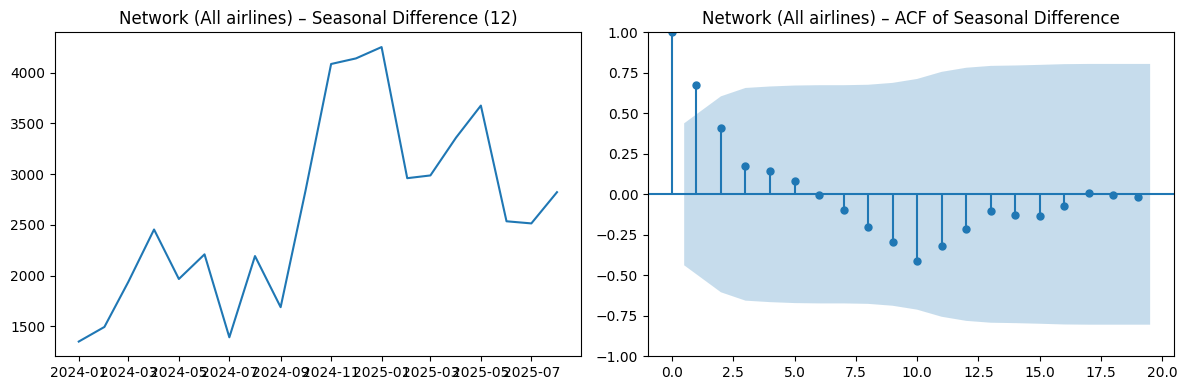


PRE-CHECKS: Cebu Pacific network
N observations: 32
Date range: 2023-01-01 to 2025-08-01
Mean: 6136.16
Std dev: 968.87
Min / Max: 4715.00 / 7876.00
Zero months: 0

ADF test
  Statistic: -1.6217
  p-value:   0.4718
  Interpretation: Non-stationary (fail to reject H0)

KPSS test
  Statistic: 0.7813
  p-value:   0.0100
  Interpretation: Non-stationary (reject H0)


/tmp/ipykernel_493/3207610546.py:43: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(y, regression="c", nlags="auto")


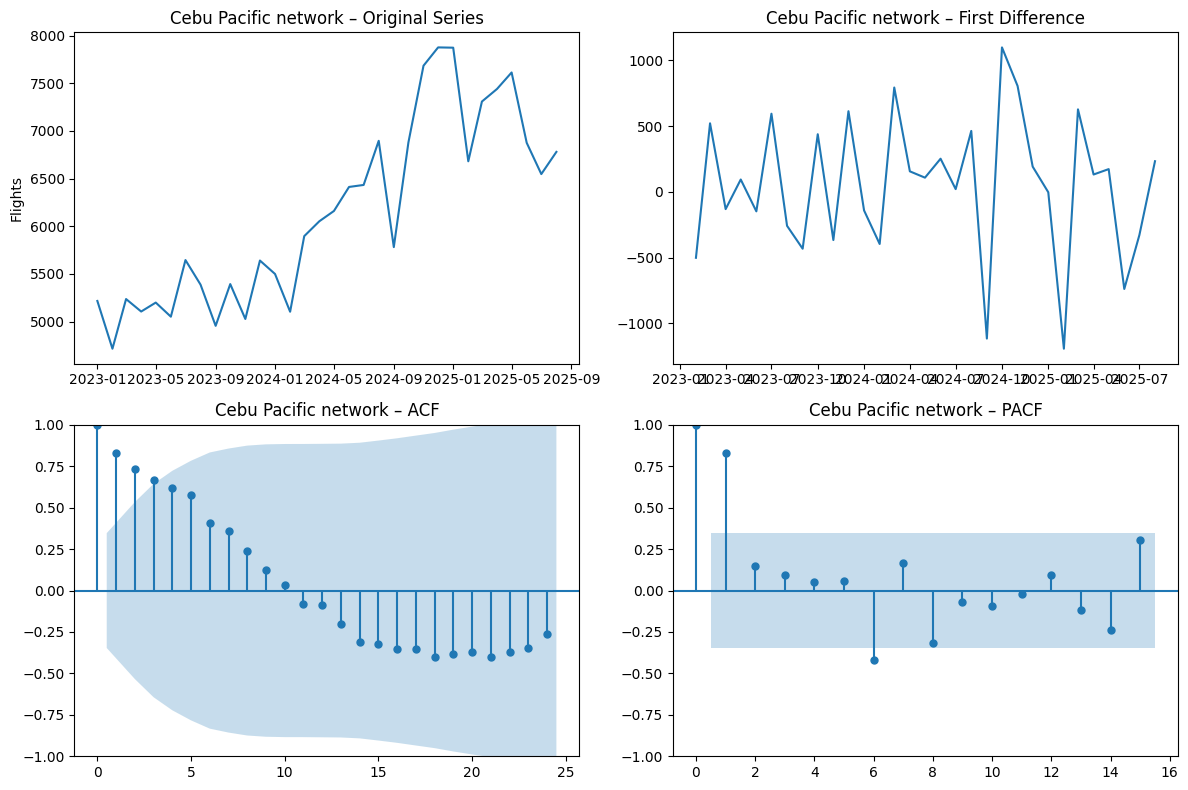

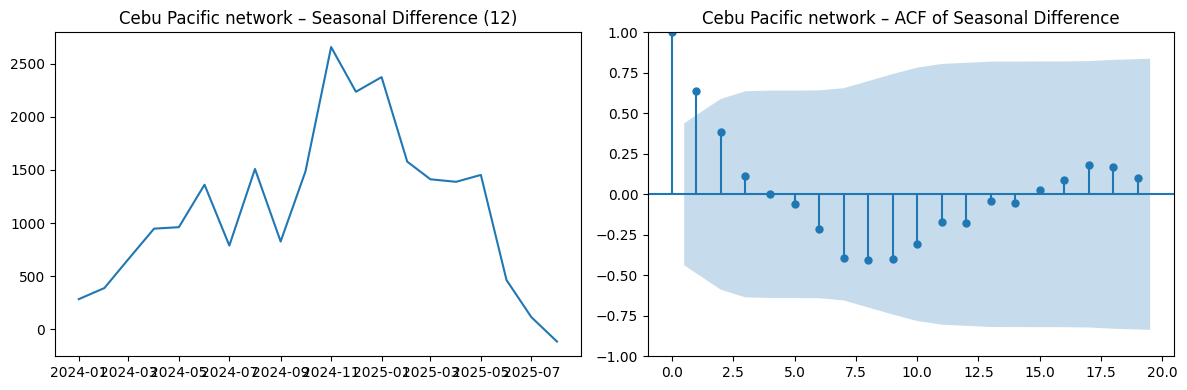


PRE-CHECKS: Route CEB-CBO
N observations: 32
Date range: 2023-01-01 to 2025-08-01
Mean: 2.31
Std dev: 4.92
Min / Max: 0.00 / 13.00
Zero months: 26

ADF test
  Statistic: 0.0714
  p-value:   0.9641
  Interpretation: Non-stationary (fail to reject H0)

KPSS test
  Statistic: 0.5172
  p-value:   0.0378
  Interpretation: Non-stationary (reject H0)


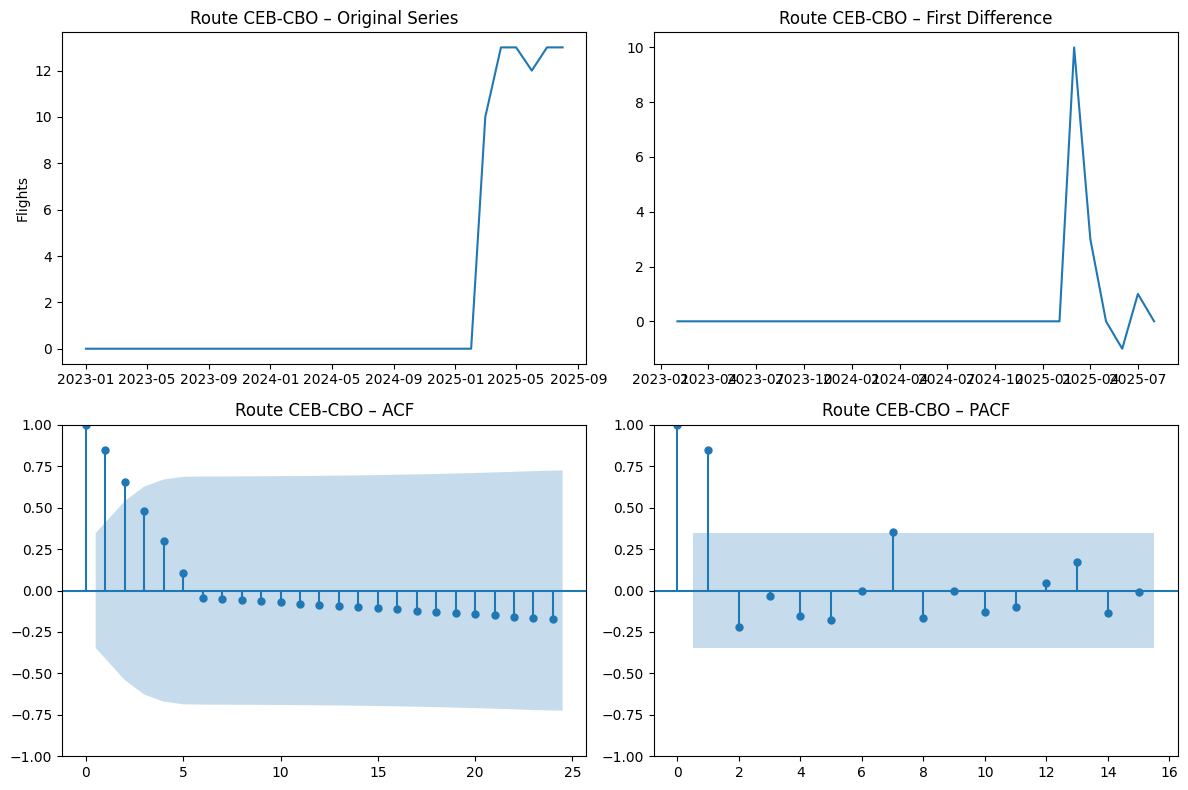

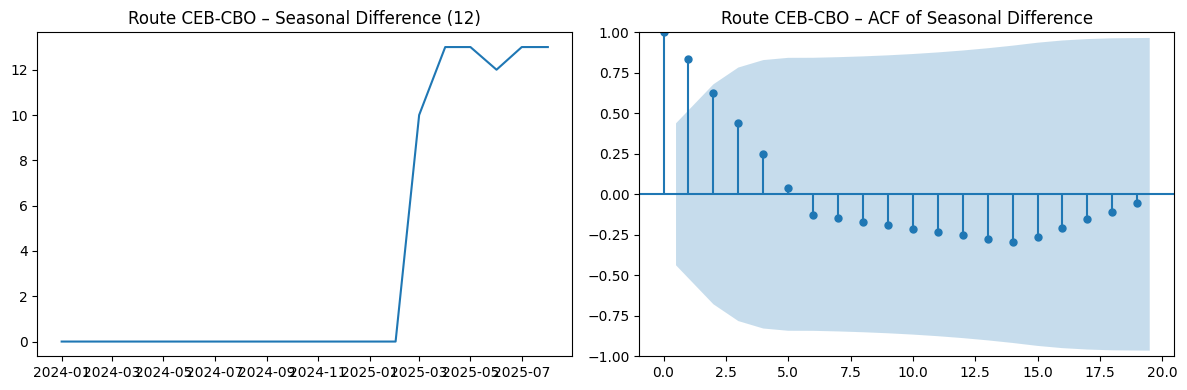


PRE-CHECKS: Route CRK-BSO
N observations: 32
Date range: 2023-01-01 to 2025-08-01
Mean: 7.12
Std dev: 9.01
Min / Max: 0.00 / 29.00
Zero months: 18

ADF test
  Statistic: 0.1017
  p-value:   0.9662
  Interpretation: Non-stationary (fail to reject H0)

KPSS test
  Statistic: 0.7568
  p-value:   0.0100
  Interpretation: Non-stationary (reject H0)


/tmp/ipykernel_493/3207610546.py:43: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_res = kpss(y, regression="c", nlags="auto")


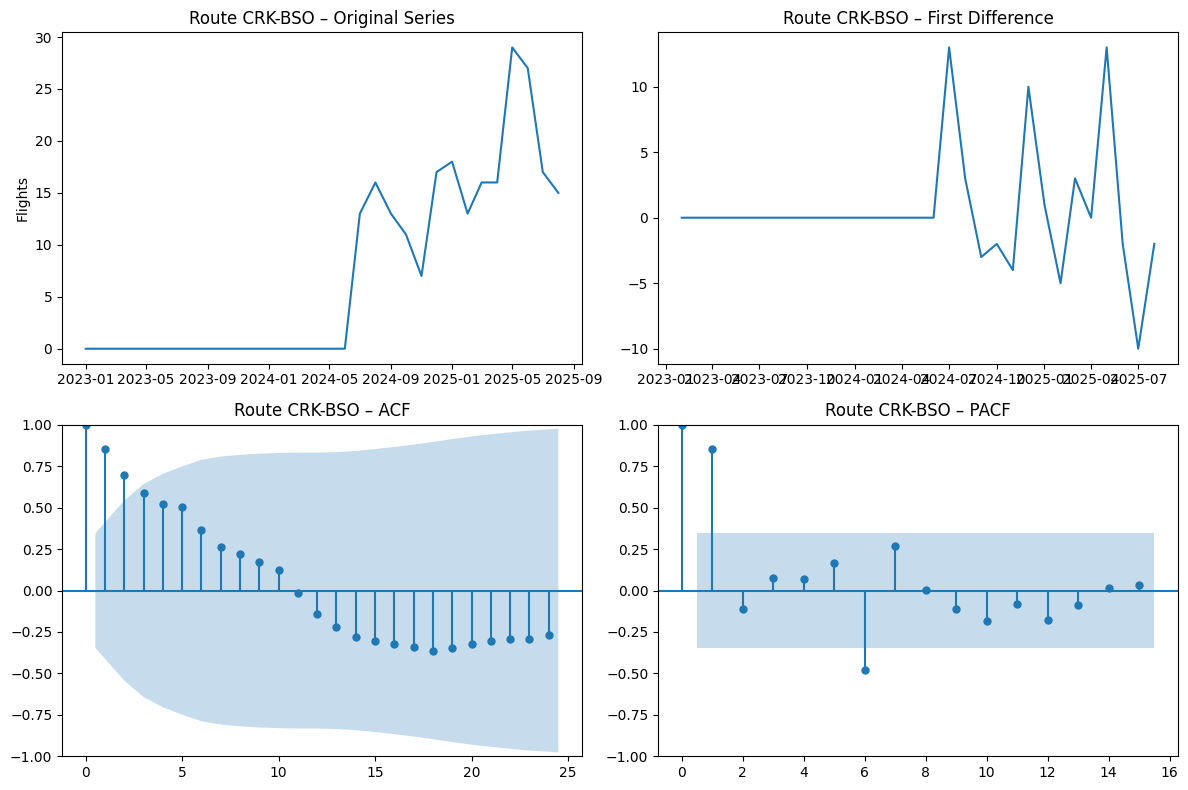

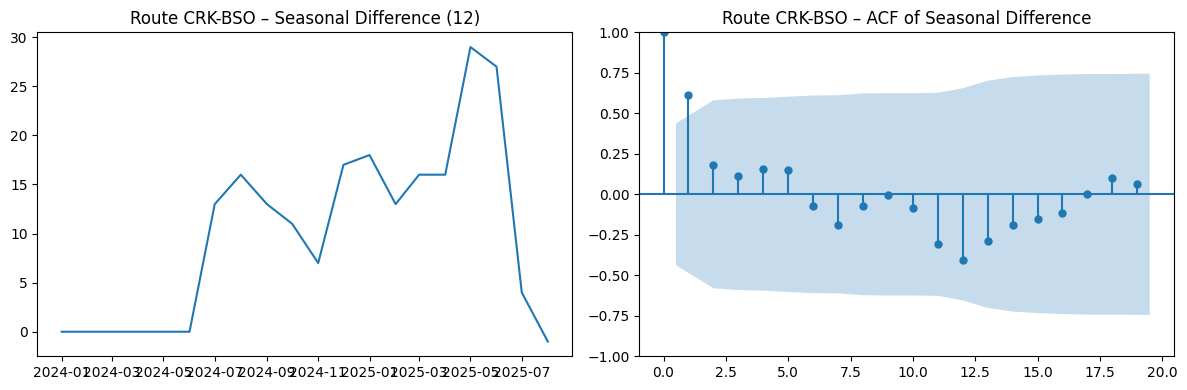


PRE-CHECKS: Route MNL-CRM
N observations: 32
Date range: 2023-01-01 to 2025-08-01
Mean: 13.75
Std dev: 2.72
Min / Max: 11.00 / 23.00
Zero months: 0

ADF test
  Statistic: -2.5509
  p-value:   0.1036
  Interpretation: Non-stationary (fail to reject H0)

KPSS test
  Statistic: 0.2745
  p-value:   0.1000
  Interpretation: Stationary (fail to reject H0)


/tmp/ipykernel_493/3207610546.py:43: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_res = kpss(y, regression="c", nlags="auto")


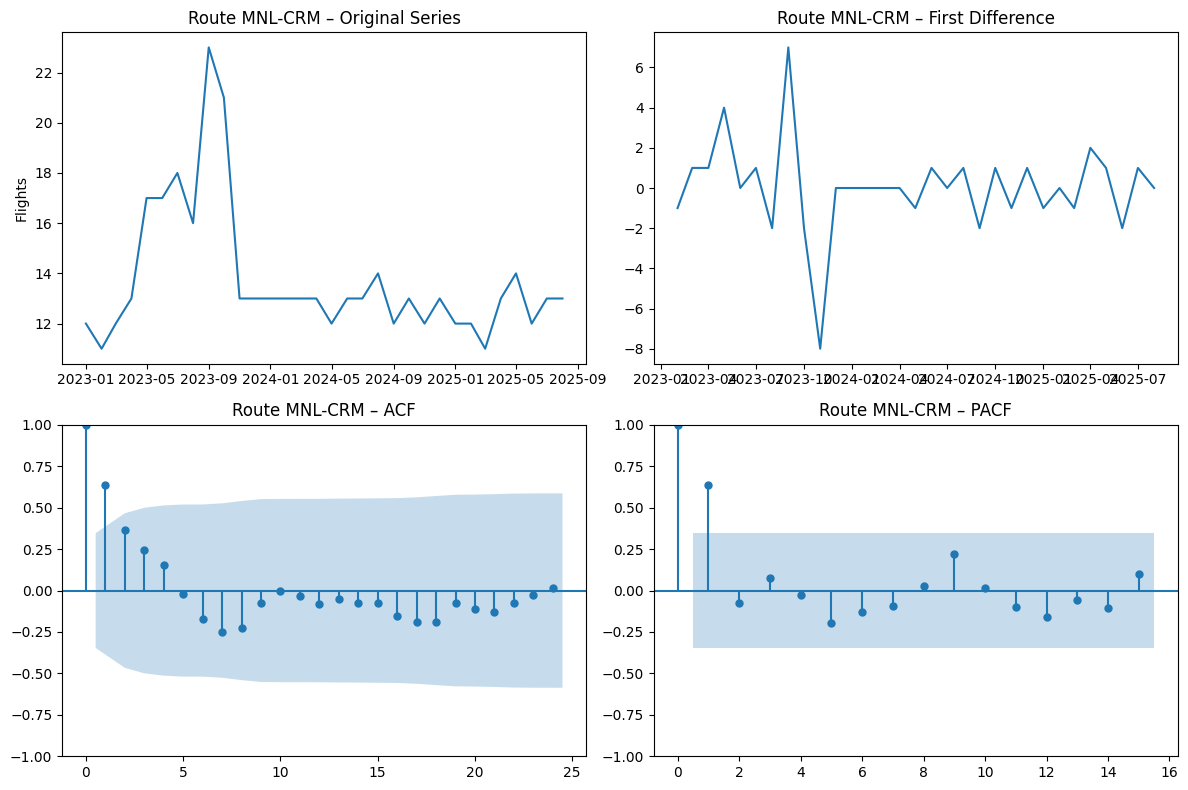

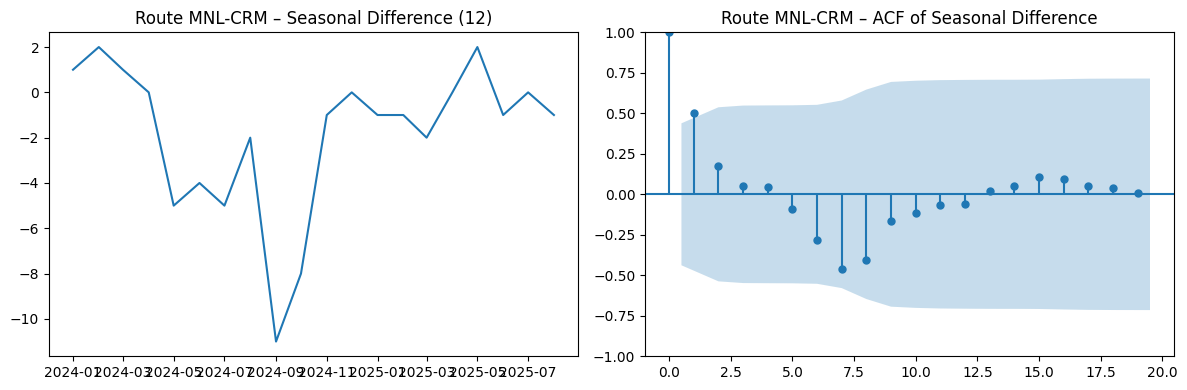

In [ ]:
check_series_assumptions(y_network, "Network (All airlines)")
check_series_assumptions(y_cebpac, "Cebu Pacific network")
check_series_assumptions(y_ceb_cbo, "Route CEB-CBO")
check_series_assumptions(y_crk_bso, "Route CRK-BSO")
check_series_assumptions(y_mnl_crm, "Route MNL-CRM")

In [ ]:
search_results_network = grid_search_sarimax(
    y_network,
    test_months=TEST_MONTHS,
    seasonal_period=12
)

search_results_network.head(15)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/sta

,model,order,seasonal_order,aic,mae,rmse,mape,smape,mase
0,SARIMA,"(2, 1, 0)","(0, 1, 0, 12)",183.001105,350.733627,445.619848,1.911626,1.934804,0.140474
1,SARIMA,"(2, 1, 0)","(0, 1, 1, 12)",8.000000,350.733627,445.619848,1.911626,1.934804,0.140474
2,SARIMA,"(2, 1, 0)","(1, 1, 1, 12)",10.000000,350.733627,445.619848,1.911626,1.934804,0.140474
3,SARIMA,"(2, 1, 2)","(0, 1, 0, 12)",170.305925,354.771308,467.146649,1.935338,1.959589,0.142091
4,SARIMA,"(1, 1, 2)","(0, 1, 0, 12)",168.648961,358.421759,460.576203,1.956157,1.979603,0.143553
5,SARIMA,"(0, 1, 0)","(0, 1, 1, 12)",4.000000,358.666667,422.683885,1.961984,1.968122,0.143651
6,SARIMA,"(0, 1, 0)","(1, 1, 1, 12)",6.000000,358.666667,422.683885,1.961984,1.968122,0.143651
7,SARIMA,"(0, 1, 0)","(0, 1, 0, 12)",195.191096,358.666667,422.683885,1.961984,1.968122,0.143651
8,SARIMA,"(0, 1, 1)","(0, 1, 1, 12)",6.000000,358.742577,422.121836,1.962601,1.965805,0.143682
9,SARIMA,"(0, 1, 1)","(1, 1, 1, 12)",8.000000,358.742577,422.121836,1.962601,1.965805,0.143682


In [ ]:
def refit_and_forecast(y, best_row, horizon=12):
    order = tuple(best_row["order"])
    seas = tuple(best_row["seasonal_order"])

    res_full = fit_sarimax(y, order=order, seasonal_order=seas)
    fc = predict_steps(res_full, horizon)

    future_idx = pd.date_range(y.index.max() + pd.offsets.MonthBegin(1), periods=horizon, freq="MS")
    fc = pd.Series(fc.values, index=future_idx, name="forecast")

    return res_full, fc

best_network = search_results_network.iloc[0]
best_network

,0
model,SARIMA
order,"(0, 1, 0)"
seasonal_order,"(1, 0, 1, 12)"
aic,170.989899
mae,134.92667
rmse,159.267708
mape,3.08697
smape,3.109644
mase,0.218986


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


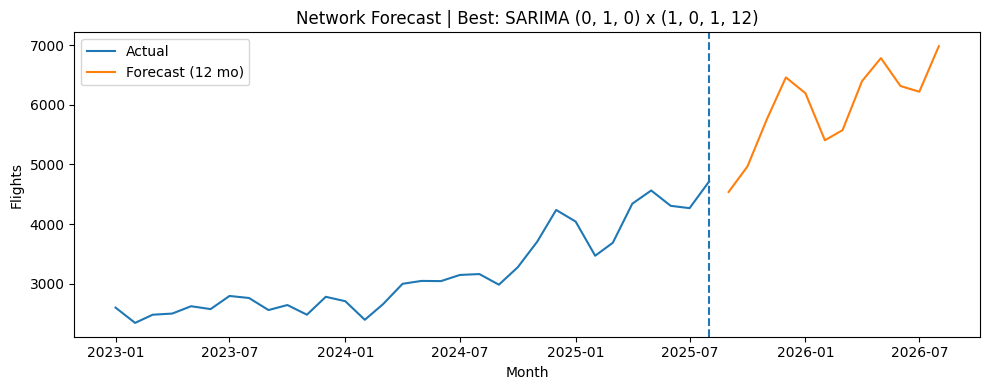

,forecast
2025-09-01,4537.701722
2025-10-01,4967.192789
2025-11-01,5761.680684
2025-12-01,6457.570503
2026-01-01,6192.907462
2026-02-01,5404.652663
2026-03-01,5573.370325
2026-04-01,6395.895746
2026-05-01,6781.060646
2026-06-01,6313.295577


In [ ]:
res_full_network, fc_network = refit_and_forecast(y_network, best_network, horizon=12)

plt.figure(figsize=(10,4))
plt.plot(y_network.index, y_network.values, label="Actual")
plt.plot(fc_network.index, fc_network.values, label="Forecast (12 mo)")
plt.axvline(y_network.index.max(), linestyle="--")
plt.title(f"Network Forecast | Best: {best_network['model']} {best_network['order']} x {best_network['seasonal_order']}")
plt.xlabel("Month")
plt.ylabel("Flights")
plt.legend()
plt.tight_layout()
plt.show()

fc_network


Running grid search: Network_AllAirlines


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimat

Best: SARIMA (0, 1, 0) x (1, 0, 1, 12)
Test metrics (best): MAE 134.93 | RMSE 159.27 | sMAPE 3.11 | MASE 0.219 | AIC 171.0


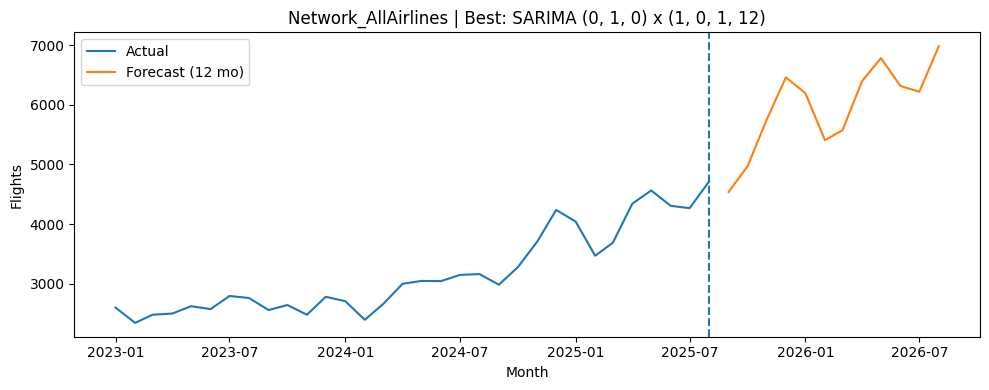


Running grid search: CebuPacific_Network


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/sta

Best: SARIMA (0, 1, 1) x (1, 0, 0, 12)
Test metrics (best): MAE 36.43 | RMSE 56.58 | sMAPE 3.15 | MASE 0.175 | AIC 160.4


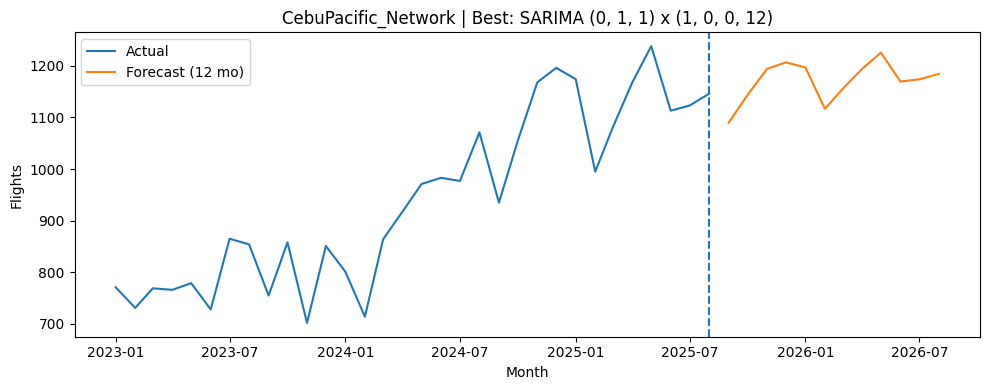


Running grid search: Route_CEB-CBO


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

Best: ARIMA (0, 1, 0) x (0, 0, 0, 0)
Test metrics (best): MAE 12.33 | RMSE 12.38 | sMAPE 200.0 | MASE NA | AIC -616.9


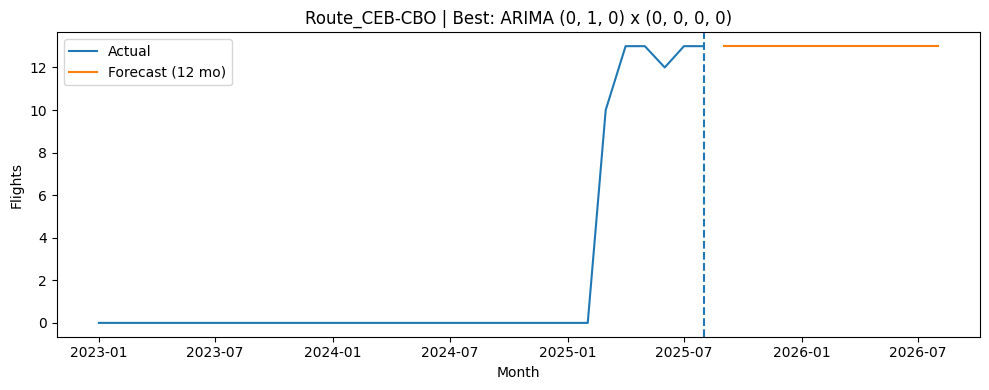


Running grid search: Route_CRK-BSO


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for va

Best: ARIMA (1, 0, 3) x (0, 0, 0, 0)
Test metrics (best): MAE 4.91 | RMSE 6.38 | sMAPE 23.5 | MASE 0.636 | AIC 127.5


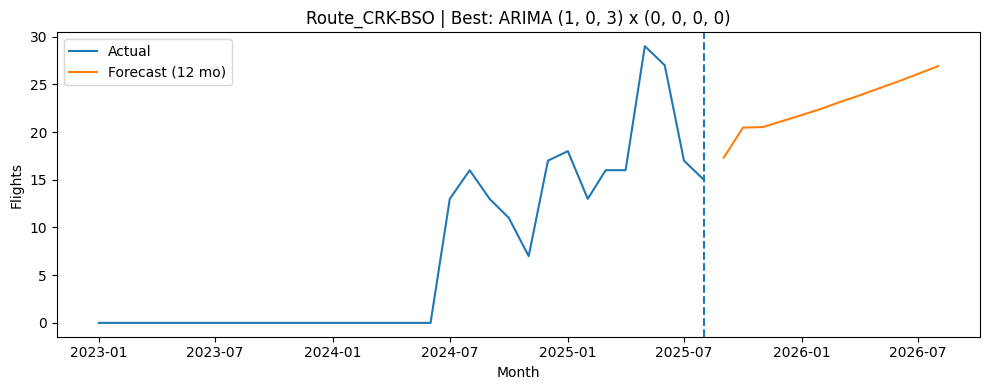


Running grid search: Route_MNL-CRM


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimat

Best: ARIMA (1, 1, 1) x (0, 0, 0, 0)
Test metrics (best): MAE 0.69 | RMSE 0.88 | sMAPE 5.52 | MASE 0.22 | AIC 114.8


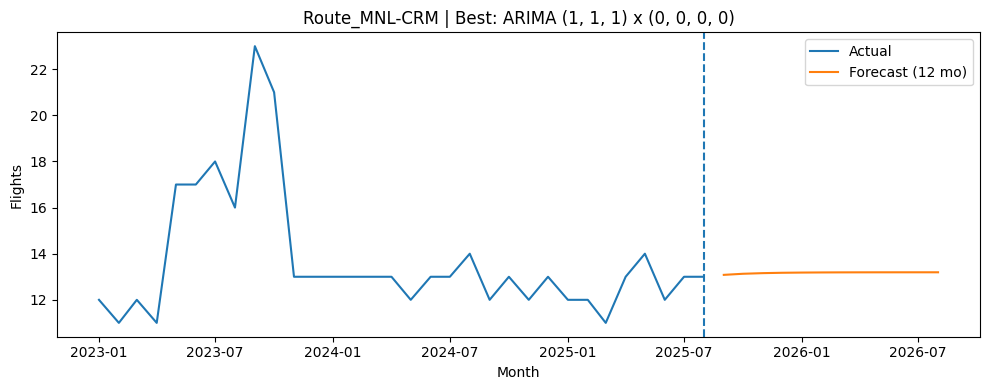

OSError: Cannot save file into a non-existent directory: '/mnt/data'

In [ ]:
all_search_tables = {}
all_forecasts = {}

for name, y in series_dict.items():
    print("\n=================================================")
    print("Running grid search:", name)
    print("=================================================")

    tbl = grid_search_sarimax(y, test_months=TEST_MONTHS, seasonal_period=12)
    all_search_tables[name] = tbl

    if tbl.empty:
        print("No successful models for", name)
        continue

    best = tbl.iloc[0]
    res_full, fc = refit_and_forecast(y, best, horizon=12)
    all_forecasts[name] = fc

    print("Best:", best["model"], best["order"], "x", best["seasonal_order"])
    print("Test metrics (best): MAE", round(best["mae"],2),
          "| RMSE", round(best["rmse"],2),
          "| sMAPE", round(best["smape"],2),
          "| MASE", round(best["mase"],3) if pd.notna(best["mase"]) else "NA",
          "| AIC", round(best["aic"],1))

    # plot
    plt.figure(figsize=(10,4))
    plt.plot(y.index, y.values, label="Actual")
    plt.plot(fc.index, fc.values, label="Forecast (12 mo)")
    plt.axvline(y.index.max(), linestyle="--")
    plt.title(f"{name} | Best: {best['model']} {best['order']} x {best['seasonal_order']}")
    plt.xlabel("Month")
    plt.ylabel("Flights")
    plt.legend()
    plt.tight_layout()
    plt.show()

# Save forecast table
fc_rows = []
for name, fc in all_forecasts.items():
    tmp = fc.reset_index()
    tmp.columns = ["Month", "Forecast_Flights"]
    tmp["Series"] = name
    fc_rows.append(tmp)